# BurstGPT 5-minute target-series EDA

## tl;dr

本 Notebook 只分析1/2号主实验批次构成的完整5分钟网格，并把所有图片保存到 `outputs/figures/`。公开时间字段是相对秒；1970日期仅为方便重采样的合成UTC轴，因此下文只讨论**相对日内时段、相对周相位和相对日编号**，不解释真实星期、周末或节假日。

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "series_5min.parquet").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
MPL_CONFIG_DIR = PROJECT_ROOT / "outputs" / ".matplotlib"
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CONFIG_DIR))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

SEED = 42
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
BLUE = "#31688E"
BLUE_LIGHT = "#A9C7D8"
GOLD = "#E69F00"
ORANGE = "#D55E00"
INK = "#232A31"
GREY = "#6B7280"
GRID = "#D9DEE5"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "font.family": "DejaVu Sans",
})

def save_and_show(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))
    return path

series_path = PROJECT_ROOT / "data" / "processed" / "series_5min.parquet"
series = pd.read_parquet(series_path)
series.index = pd.DatetimeIndex(pd.to_datetime(series.index, utc=True))
series.index.name = "timestamp"
threshold_table = pd.read_csv(PROJECT_ROOT / "outputs" / "tables" / "table_01_burst_threshold.csv")
TRAIN_P95 = float(threshold_table.loc[0, "p95_threshold"])

assert series.index.is_unique and series.index.is_monotonic_increasing
assert series.index.to_series().diff().dropna().eq(pd.Timedelta(minutes=5)).all()
assert series.loc[series["request_count"].eq(0), ["mean_request_tokens", "mean_response_tokens"]].isna().all().all()

zero_share = float(series["is_zero_window"].mean())
load_cv = float(series["token_load"].std() / series["token_load"].mean())
spearman = float(series[["request_count", "token_load"]].corr(method="spearman").iloc[0, 1])
display(Markdown(
    f"**执行摘要。** 完整网格含 **{len(series):,}** 个窗口，零负载窗占 **{zero_share:.2%}**；"
    f"训练期固定 P95 为 **{TRAIN_P95:,.2f} Token/5min**。请求数与Token负载的Spearman相关系数为 **{spearman:.3f}**，"
    f"说明请求量是重要但不充分的负载解释变量。"
))

**执行摘要。** 完整网格含 **34,848** 个窗口，零负载窗占 **19.43%**；训练期固定 P95 为 **315,246.20 Token/5min**。请求数与Token负载的Spearman相关系数为 **0.975**，说明请求量是重要但不充分的负载解释变量。

## Context & Methods

### Key Assumptions

- 输入：`data/processed/requests_1.parquet`、`requests_2.parquet` 经 `src/02_build_series.py` 聚合得到的 `series_5min.parquet`。
- 时间窗：左闭右开 `[t, t+5min)`；零请求窗保留，Token负载和计数为0，均值为NaN。
- 切分和突发：按时间70%/15%/15%，P95只在训练段计算并固定用于三段。
- 图表问题限定为特征设计、朴素基线和结果讨论；不会把相对周相位解释为真实星期或周末。

## Data

In [2]:
data_summary = pd.DataFrame({
    "value": [
        series.index.min().isoformat(),
        series.index.max().isoformat(),
        len(series),
        int(series["request_count"].sum()),
        int(series["token_load"].sum()),
        int(series["is_zero_window"].sum()),
        TRAIN_P95,
    ]
}, index=[
    "first synthetic UTC bin", "last synthetic UTC bin", "5-minute windows",
    "requests", "tokens", "zero windows", "train-only P95"
])
display(data_summary)
display(series.head(3))

,value
first synthetic UTC bin,1970-01-01T00:00:00+00:00
last synthetic UTC bin,1970-05-01T23:55:00+00:00
5-minute windows,34848
requests,5058910
tokens,2146868147
zero windows,6771
train-only P95,315246.2


,token_load,request_count,mean_request_tokens,mean_response_tokens,gpt4_request_count,chatgpt_request_count,api_request_count,conversation_request_count,batch_1_request_count,batch_2_request_count,source_batch,is_zero_window,split,actual_burst
timestamp,,,,,,,,,,,,,,
1970-01-01 00:00:00+00:00,8036,8,524.75,479.75,2,6,0,8,8,0,1,False,train,False
1970-01-01 00:05:00+00:00,3312,3,722.00,382.00,1,2,0,3,3,0,1,False,train,False
1970-01-01 00:10:00+00:00,4217,5,613.00,230.40,2,3,0,5,5,0,1,False,train,False


## Results

### Figure 01 — Complete 5-minute load trend

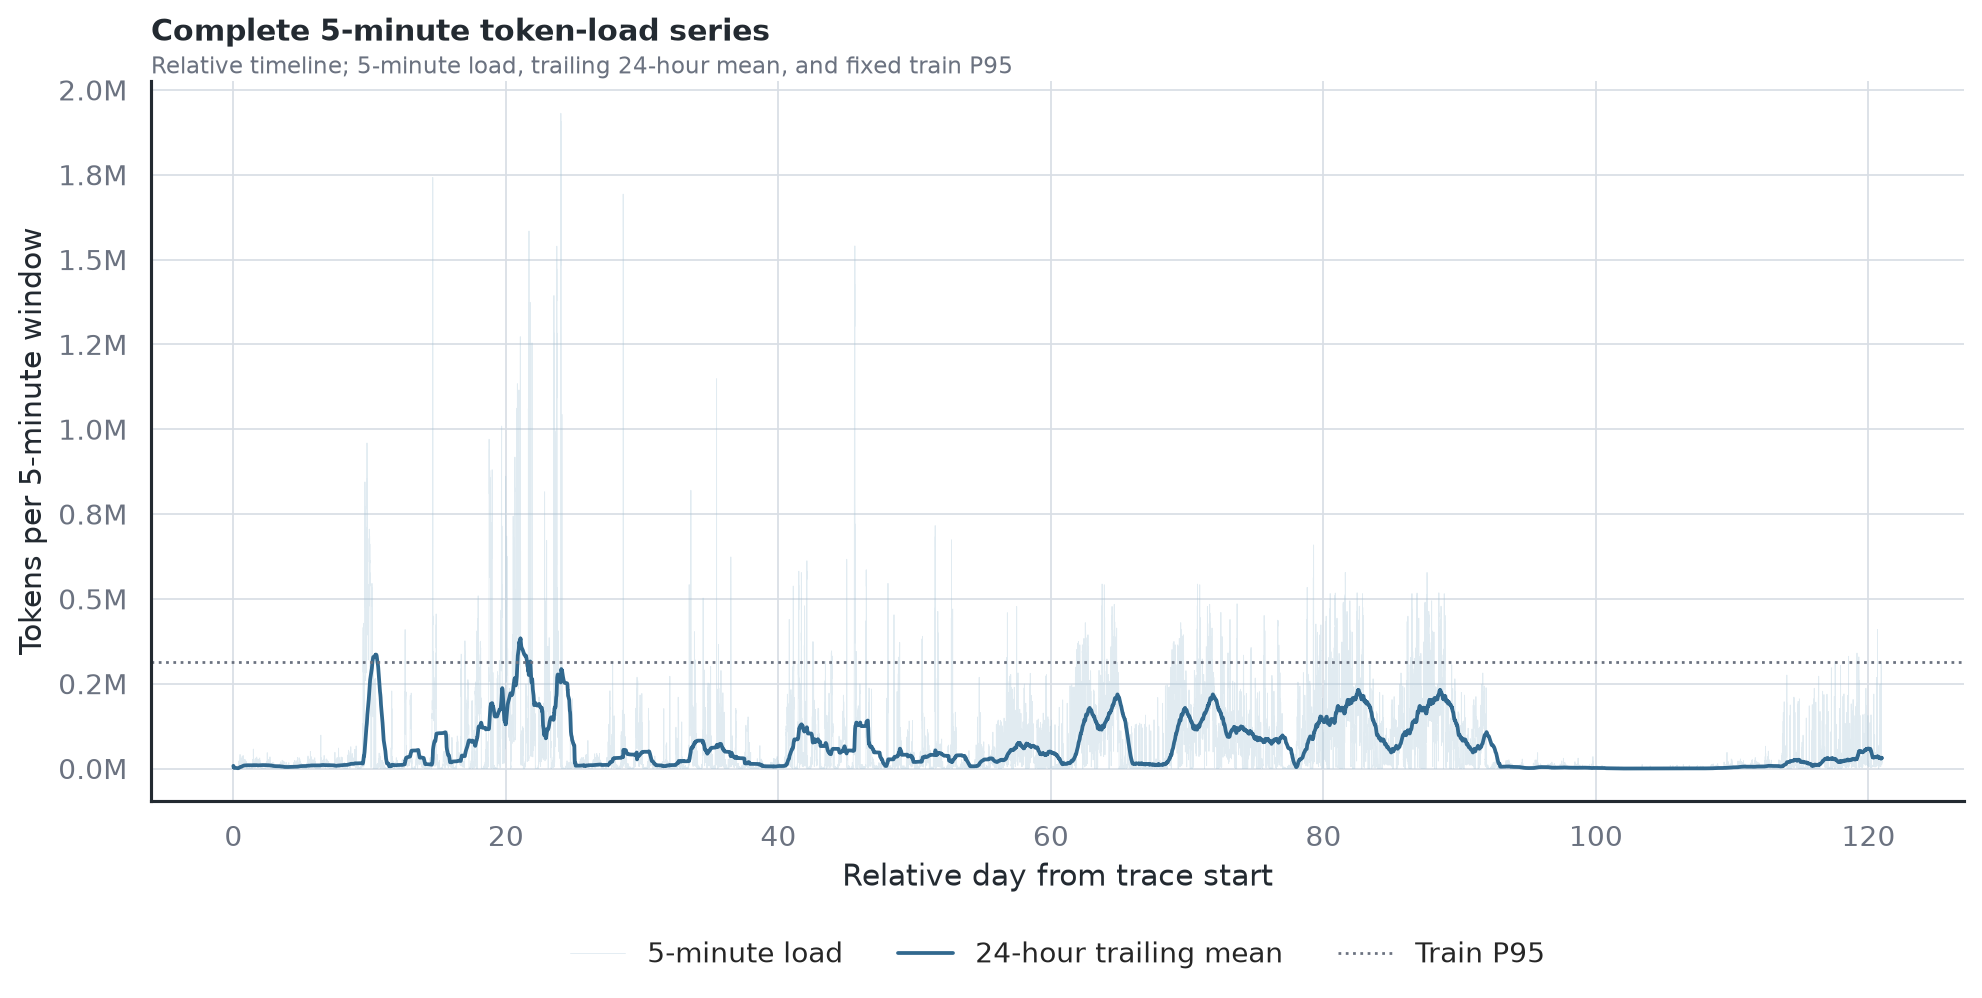

**观察：** 负载变异系数为 **1.99**，并存在明显的长尾尖峰；后半段24小时滚动均值中位数是前半段的 **0.78 倍**。这支持使用滞后/滚动特征，同时提示固定训练阈值在后续分布漂移下可能失配。

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.2))
relative_days = (series.index - series.index.min()).total_seconds() / 86_400
ax.plot(relative_days, series["token_load"], color=BLUE_LIGHT, linewidth=0.35, alpha=0.35, label="5-minute load")
rolling_day = series["token_load"].rolling(288, min_periods=1).mean()
ax.plot(relative_days, rolling_day, color=BLUE, linewidth=1.5, label="24-hour trailing mean")
ax.axhline(TRAIN_P95, color=GREY, linewidth=1.1, linestyle=":", label="Train P95")
ax.set_title("Complete 5-minute token-load series", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, "Relative timeline; 5-minute load, trailing 24-hour mean, and fixed train P95", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Relative day from trace start")
ax.set_ylabel("Tokens per 5-minute window")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda value, _: f"{value / 1e6:.1f}M"))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.16))
save_and_show(fig, "fig_01_full_series_trend.png")
first_half = rolling_day.iloc[:len(series)//2].median()
second_half = rolling_day.iloc[len(series)//2:].median()
display(Markdown(
    f"**观察：** 负载变异系数为 **{load_cv:.2f}**，并存在明显的长尾尖峰；后半段24小时滚动均值中位数是前半段的 **{second_half / max(first_half, 1):.2f} 倍**。"
    "这支持使用滞后/滚动特征，同时提示固定训练阈值在后续分布漂移下可能失配。"
))

### Figure 02 — Representative relative week at 5-minute resolution

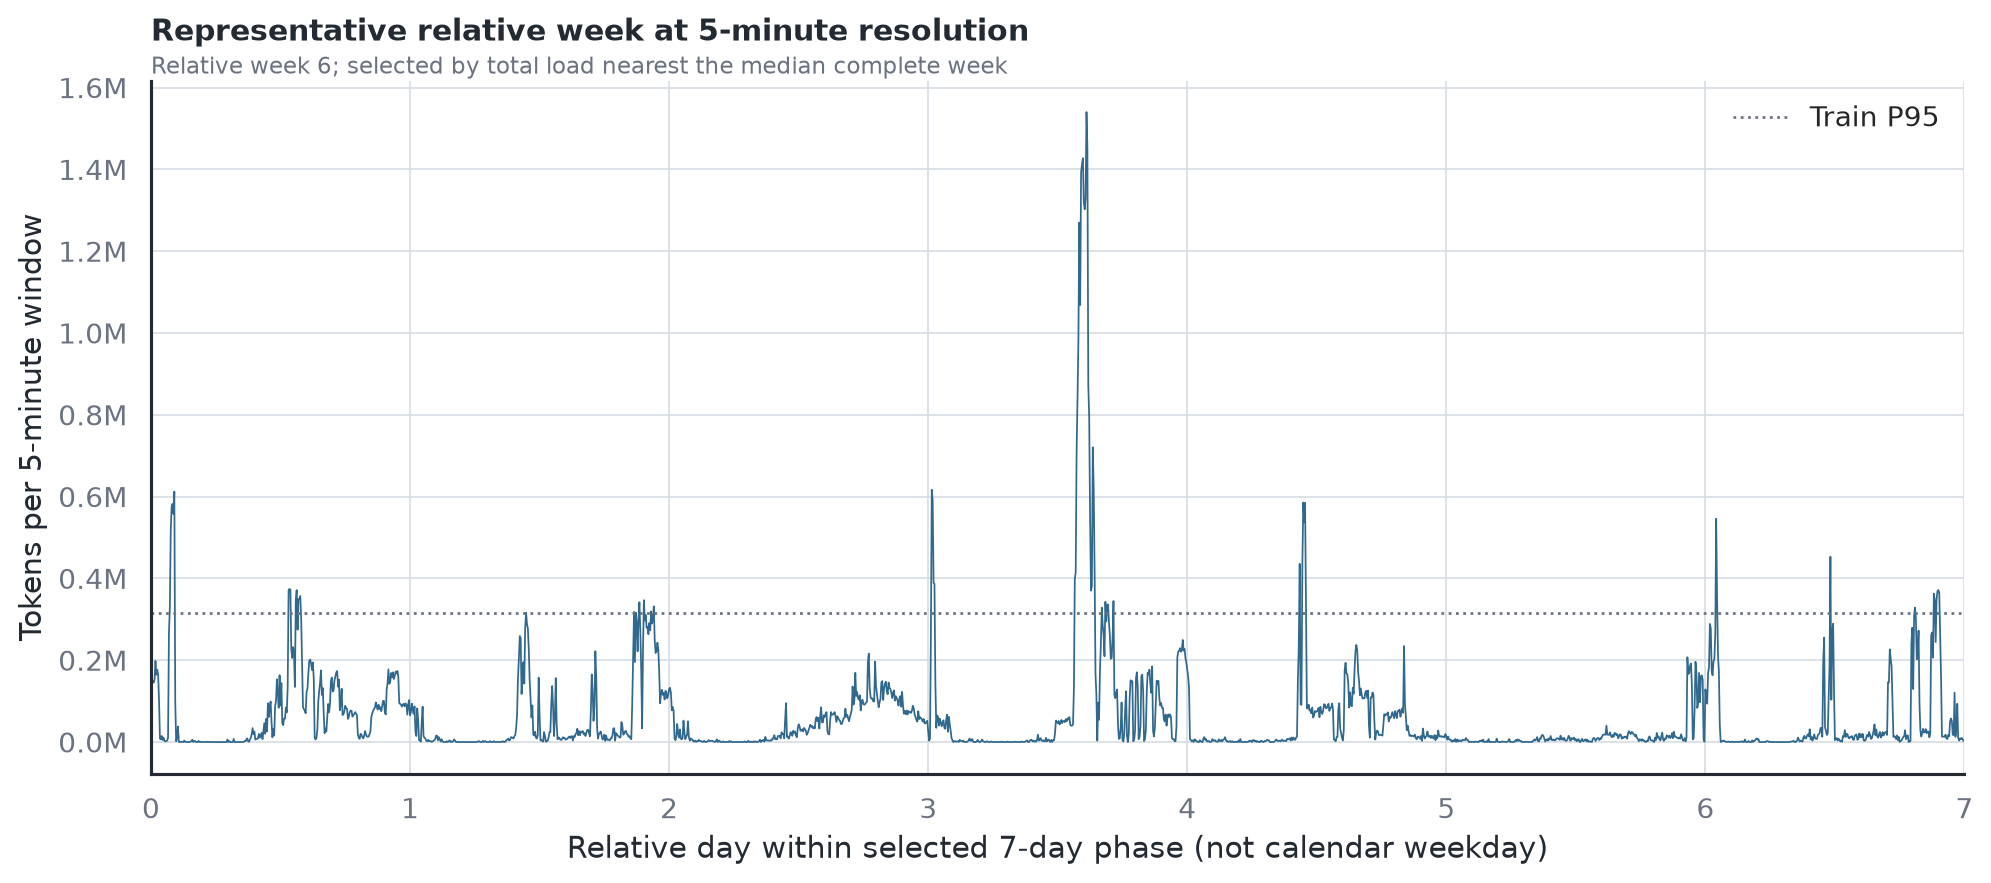

**观察：** 典型完整周内仍有强烈的窗间波动，最大负载位于相对周相位 **3.61 天**。该相位只用于周期特征与季节朴素基线，不代表真实星期几。

In [4]:
week_id = ((series.index - series.index.min()) // pd.Timedelta(days=7)).astype(int)
week_stats = series.assign(relative_week=week_id).groupby("relative_week").agg(
    n_rows=("token_load", "size"), total_load=("token_load", "sum")
)
complete_weeks = week_stats.loc[week_stats["n_rows"].eq(7 * 288)]
median_week_load = complete_weeks["total_load"].median()
representative_week = int((complete_weeks["total_load"] - median_week_load).abs().idxmin())
week_data = series.loc[week_id == representative_week]
phase_days = np.arange(len(week_data)) / 288
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(phase_days, week_data["token_load"], color=BLUE, linewidth=0.7)
ax.axhline(TRAIN_P95, color=GREY, linestyle=":", linewidth=1.1, label="Train P95")
ax.set_title("Representative relative week at 5-minute resolution", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, f"Relative week {representative_week}; selected by total load nearest the median complete week", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Relative day within selected 7-day phase (not calendar weekday)")
ax.set_ylabel("Tokens per 5-minute window")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda value, _: f"{value / 1e6:.1f}M"))
ax.set_xlim(0, 7)
ax.set_xticks(range(8))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
save_and_show(fig, "fig_02_representative_relative_week.png")
peak_position = int(np.argmax(week_data["token_load"].to_numpy()))
display(Markdown(
    f"**观察：** 典型完整周内仍有强烈的窗间波动，最大负载位于相对周相位 **{peak_position / 288:.2f} 天**。"
    "该相位只用于周期特征与季节朴素基线，不代表真实星期几。"
))

### Figure 03 — Mean load by relative day-in-week and time-of-day phase

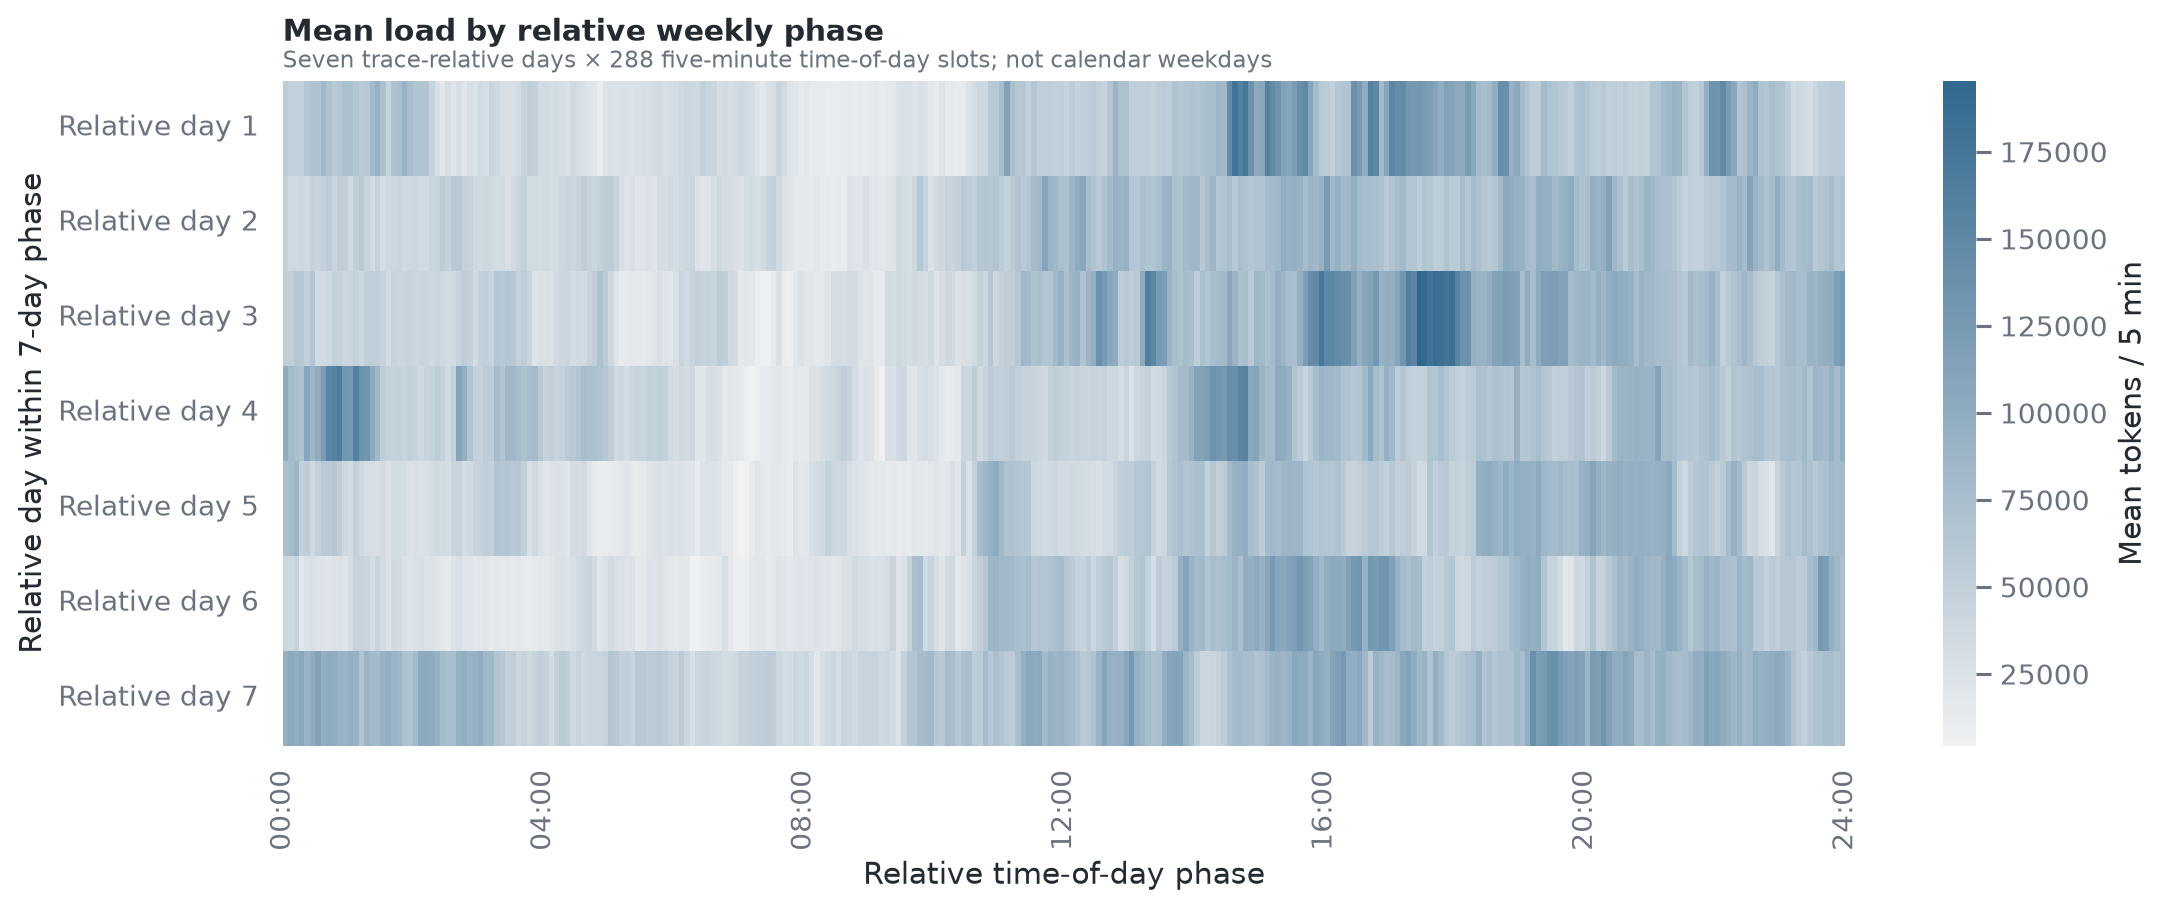

**观察：** 平均负载最高的相对相位是第 **3** 个相对日、约 **17:25**。相位结构可支持正余弦周期特征，但不能据此声称存在真实工作日/周末效应。

In [5]:
phase = pd.DataFrame(index=series.index)
elapsed_bins = np.arange(len(series))
phase["relative_day_in_week"] = (elapsed_bins // 288) % 7
phase["slot_in_day"] = elapsed_bins % 288
phase["token_load"] = series["token_load"].to_numpy()
heatmap = phase.pivot_table(index="relative_day_in_week", columns="slot_in_day", values="token_load", aggfunc="mean")
fig, ax = plt.subplots(figsize=(14, 4.8))
sns.heatmap(heatmap, cmap=sns.light_palette(BLUE, as_cmap=True), ax=ax, cbar_kws={"label": "Mean tokens / 5 min"})
ticks = np.arange(0, 289, 48)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(value // 12):02d}:00" for value in ticks])
ax.set_yticklabels([f"Relative day {value + 1}" for value in heatmap.index], rotation=0)
ax.set_title("Mean load by relative weekly phase", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.02, "Seven trace-relative days × 288 five-minute time-of-day slots; not calendar weekdays", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Relative time-of-day phase")
ax.set_ylabel("Relative day within 7-day phase")
save_and_show(fig, "fig_03_relative_week_phase_heatmap.png")
peak_day, peak_slot = np.unravel_index(np.nanargmax(heatmap.to_numpy()), heatmap.shape)
display(Markdown(
    f"**观察：** 平均负载最高的相对相位是第 **{peak_day + 1}** 个相对日、约 **{peak_slot // 12:02d}:{(peak_slot % 12) * 5:02d}**。"
    "相位结构可支持正余弦周期特征，但不能据此声称存在真实工作日/周末效应。"
))

### Figure 04 — Log-transformed token-load distribution

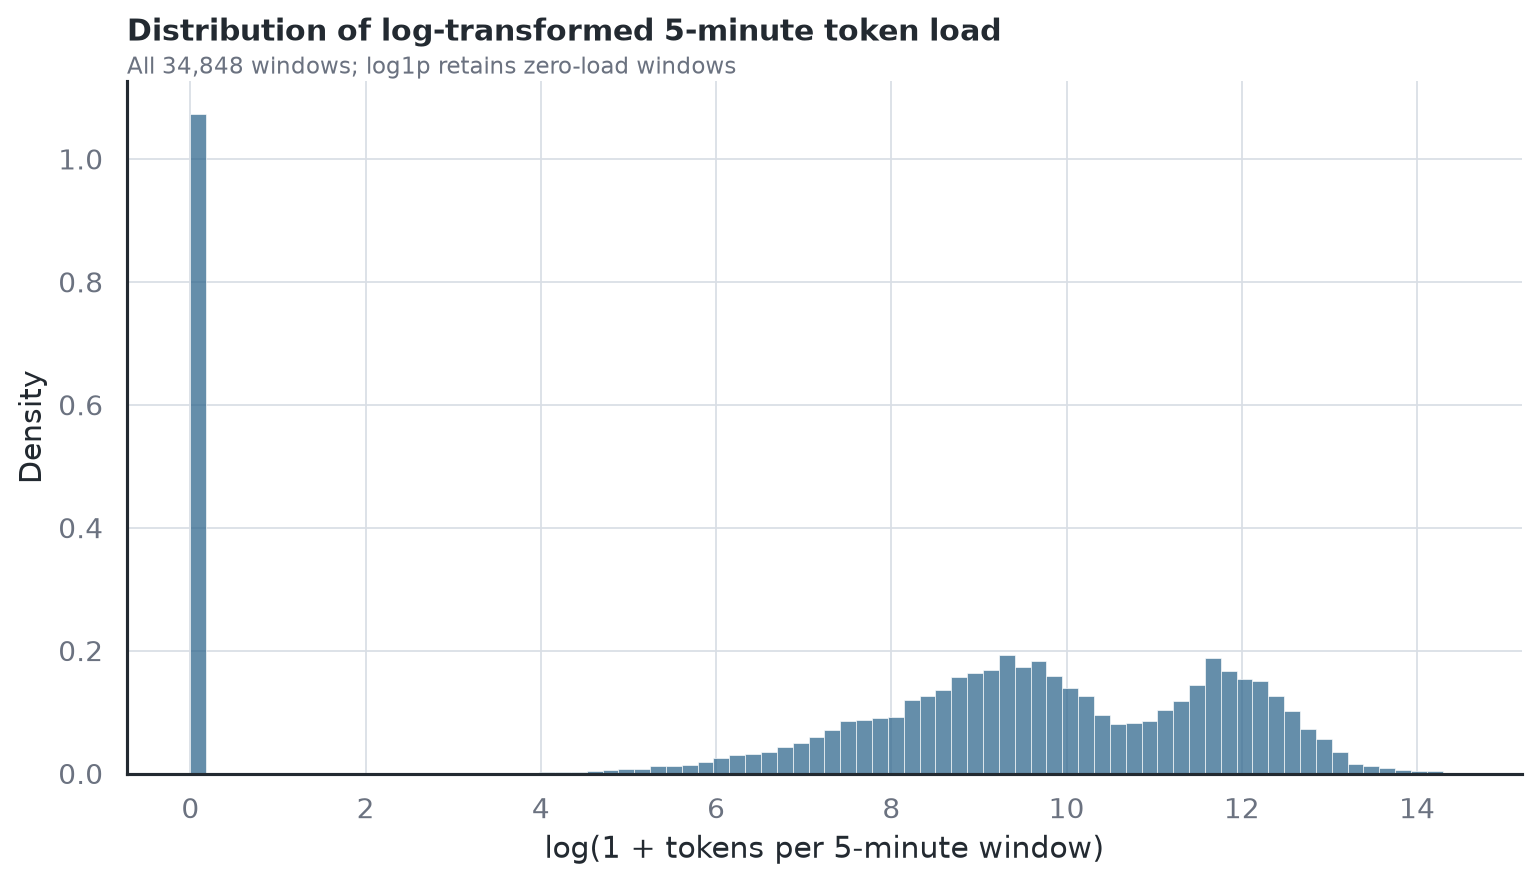

**观察：** 原尺度中位数/P95/P99分别为 **10,383 / 283,647 / 533,844 Token**，零窗占 **19.43%**。长尾性支持训练时比较原尺度与log1p目标，但评价仍应回到Token原尺度。

In [6]:
log_load = np.log1p(series["token_load"].to_numpy(dtype=float))
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(log_load, bins=80, stat="density", color=BLUE, edgecolor="white", linewidth=0.25, ax=ax)
ax.set_title("Distribution of log-transformed 5-minute token load", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, f"All {len(series):,} windows; log1p retains zero-load windows", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("log(1 + tokens per 5-minute window)")
ax.set_ylabel("Density")
ax.spines[["top", "right"]].set_visible(False)
save_and_show(fig, "fig_04_token_load_log_distribution.png")
q50, q95, q99 = series["token_load"].quantile([0.50, 0.95, 0.99]).to_numpy()
display(Markdown(
    f"**观察：** 原尺度中位数/P95/P99分别为 **{q50:,.0f} / {q95:,.0f} / {q99:,.0f} Token**，零窗占 **{zero_share:.2%}**。"
    "长尾性支持训练时比较原尺度与log1p目标，但评价仍应回到Token原尺度。"
))

### Figure 05 — Request count versus token load

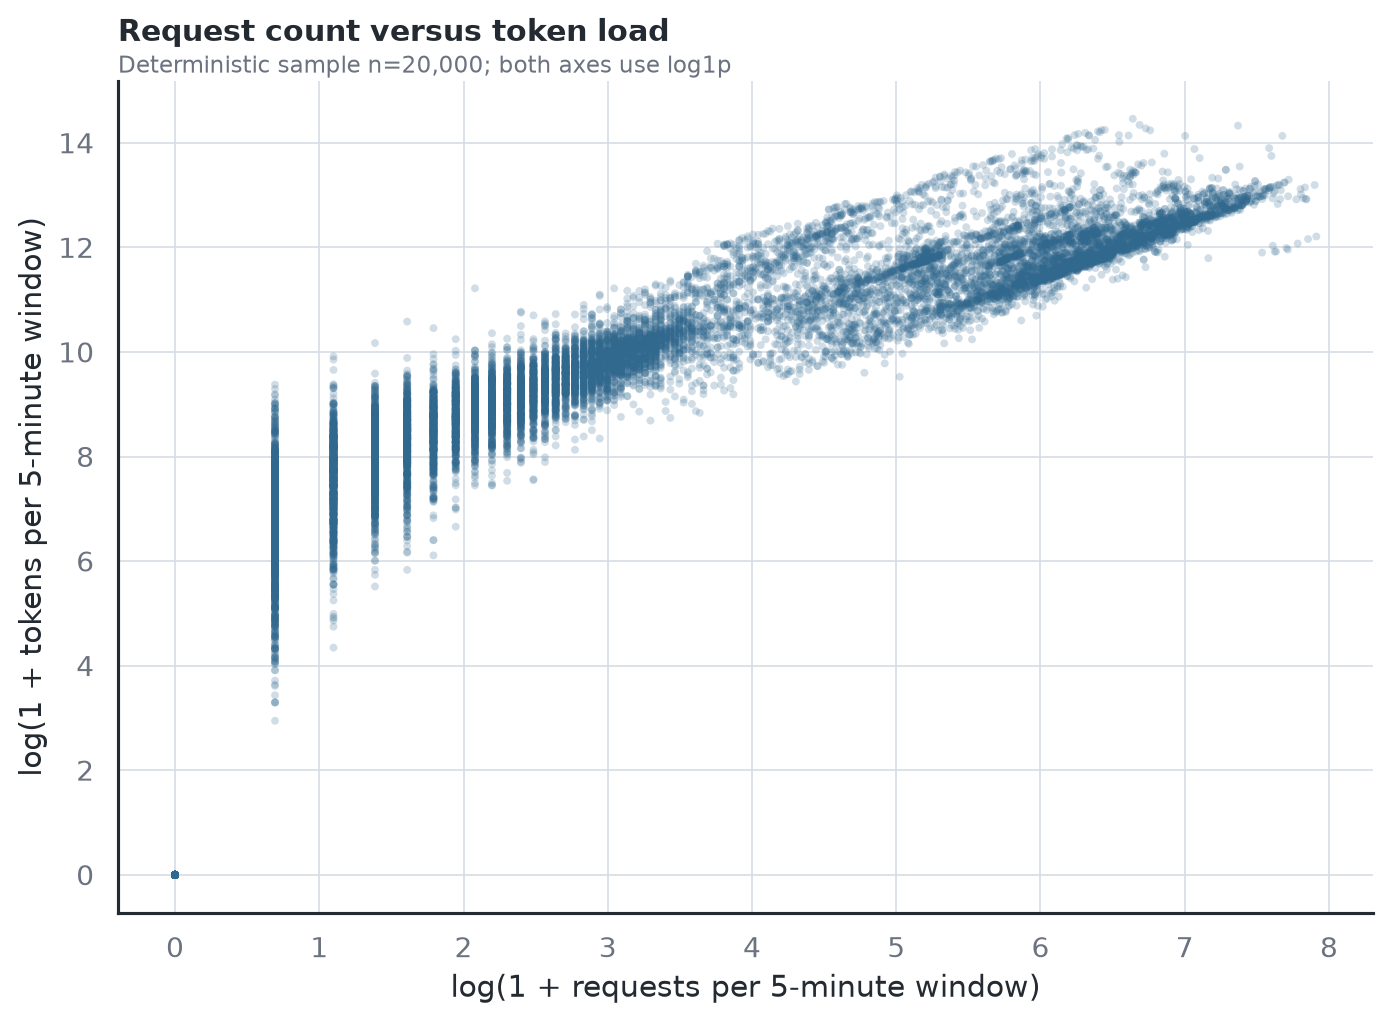

**观察：** 请求数与Token负载呈强单调关系（Spearman **0.975**），但同一请求量仍对应较宽的负载带。因此历史请求数值得作为特征，平均请求/响应Token和模型构成也可能补充解释单次请求大小差异。

In [7]:
scatter_data = series[["request_count", "token_load", "split"]]
if len(scatter_data) > 20_000:
    scatter_data = scatter_data.sample(20_000, random_state=SEED)
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    np.log1p(scatter_data["request_count"]),
    np.log1p(scatter_data["token_load"]),
    s=10, alpha=0.22, color=BLUE, edgecolors="none"
)
ax.set_title("Request count versus token load", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, f"Deterministic sample n={len(scatter_data):,}; both axes use log1p", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("log(1 + requests per 5-minute window)")
ax.set_ylabel("log(1 + tokens per 5-minute window)")
ax.spines[["top", "right"]].set_visible(False)
save_and_show(fig, "fig_05_request_count_vs_token_load.png")
display(Markdown(
    f"**观察：** 请求数与Token负载呈强单调关系（Spearman **{spearman:.3f}**），但同一请求量仍对应较宽的负载带。"
    "因此历史请求数值得作为特征，平均请求/响应Token和模型构成也可能补充解释单次请求大小差异。"
))

### Figure 06 — Model request mix over relative time

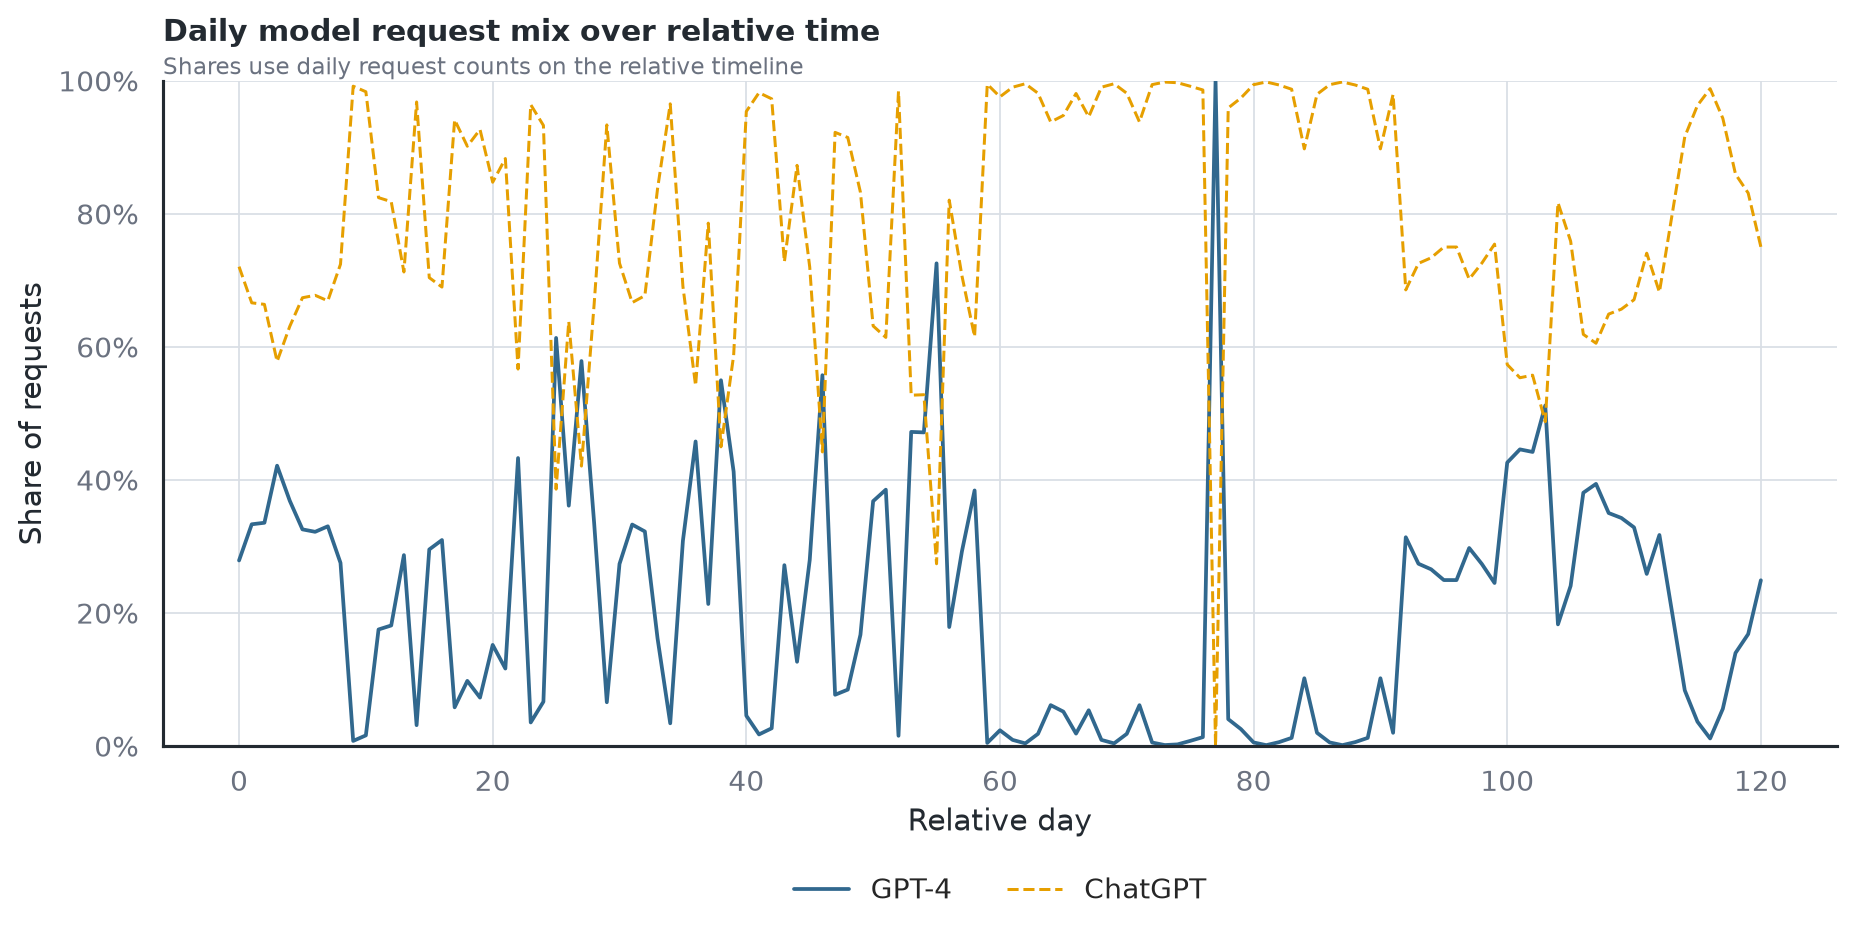

**观察：** GPT-4日请求占比在 **0.16%–100.00%** 之间变化，模型构成并非常数。预测特征只能使用预测时点以前的构成统计，不能使用未来窗口实际模型占比。

In [8]:
daily = series[["request_count", "gpt4_request_count", "chatgpt_request_count", "api_request_count", "conversation_request_count"]].resample("1D").sum()
daily["gpt4_share"] = daily["gpt4_request_count"].div(daily["request_count"].replace(0, np.nan))
daily["chatgpt_share"] = daily["chatgpt_request_count"].div(daily["request_count"].replace(0, np.nan))
daily_relative_day = np.arange(len(daily))
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(daily_relative_day, daily["gpt4_share"], color=BLUE, linewidth=1.5, label="GPT-4")
ax.plot(daily_relative_day, daily["chatgpt_share"], color=GOLD, linewidth=1.2, linestyle="--", label="ChatGPT")
ax.set_title("Daily model request mix over relative time", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, "Shares use daily request counts on the relative timeline", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Relative day")
ax.set_ylabel("Share of requests")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
save_and_show(fig, "fig_06_model_share_over_time.png")
gpt4_min, gpt4_max = daily["gpt4_share"].min(), daily["gpt4_share"].max()
display(Markdown(
    f"**观察：** GPT-4日请求占比在 **{gpt4_min:.2%}–{gpt4_max:.2%}** 之间变化，模型构成并非常数。"
    "预测特征只能使用预测时点以前的构成统计，不能使用未来窗口实际模型占比。"
))

### Figure 07 — Log Type request mix over relative time

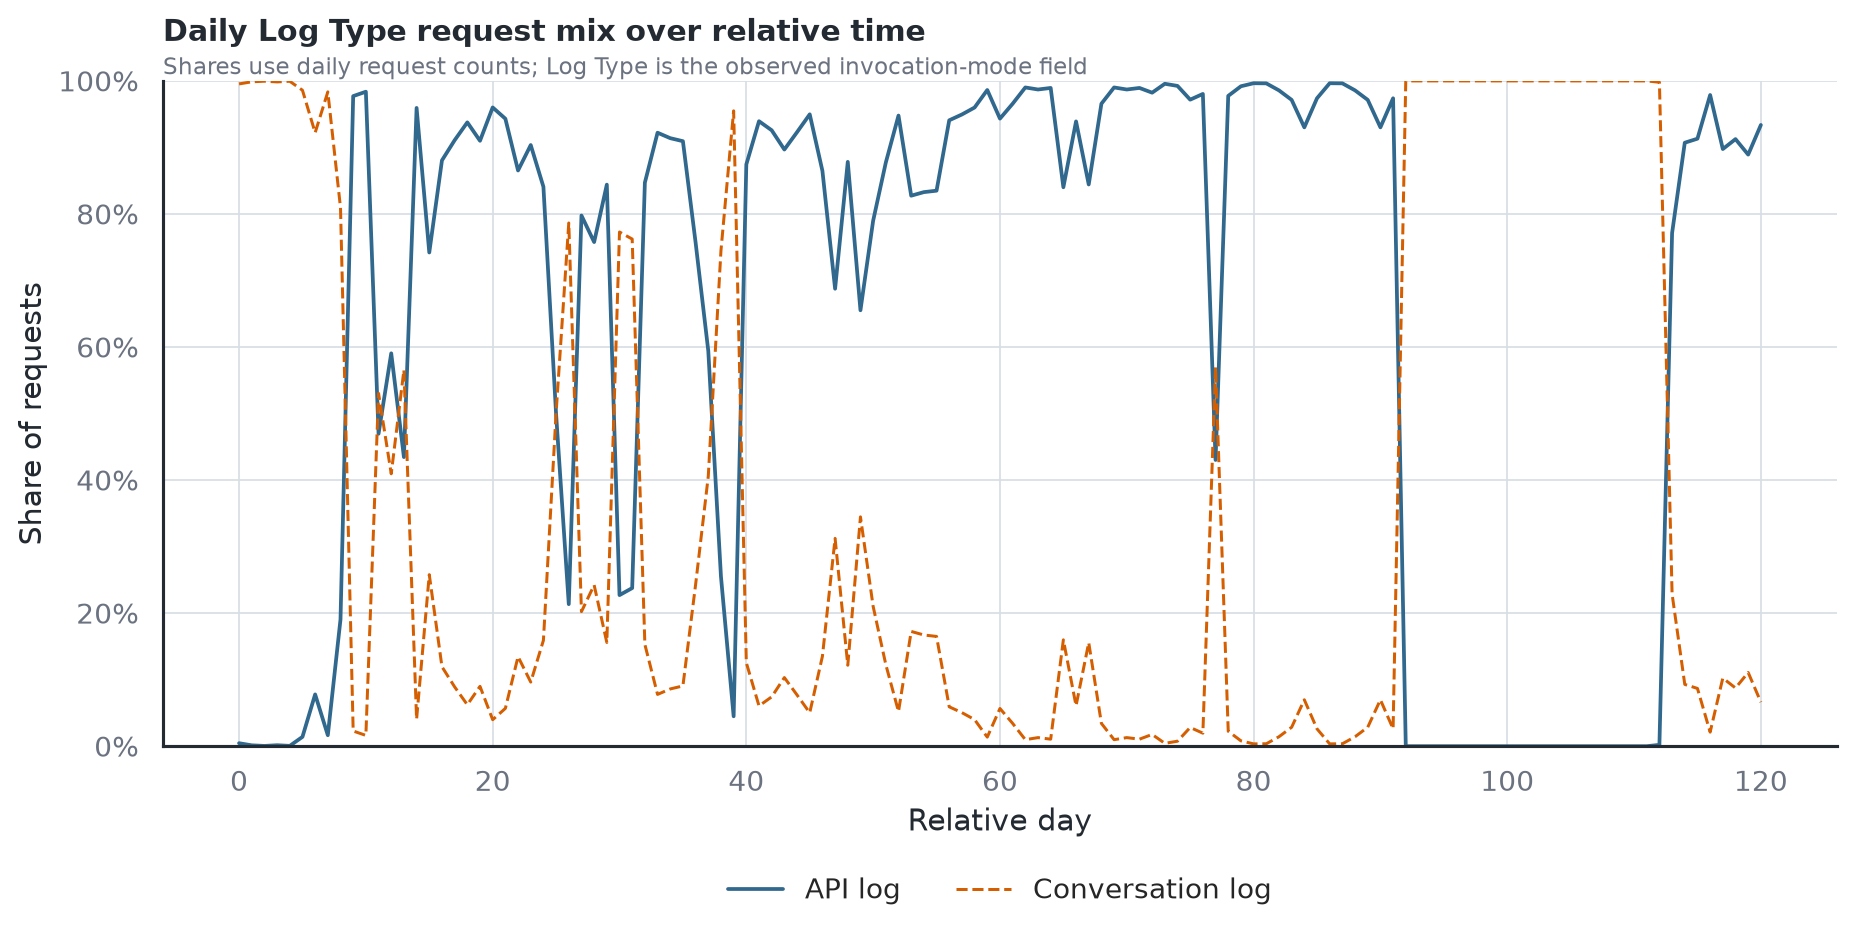

**观察：** API log日占比在 **0.00%–99.65%** 之间变化，且批次间构成差异会形成时间漂移。历史API占比可作为滞后特征；未来窗口的Log Type构成不可直接输入模型。

In [9]:
daily["api_share"] = daily["api_request_count"].div(daily["request_count"].replace(0, np.nan))
daily["conversation_share"] = daily["conversation_request_count"].div(daily["request_count"].replace(0, np.nan))
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(daily_relative_day, daily["api_share"], color=BLUE, linewidth=1.5, label="API log")
ax.plot(daily_relative_day, daily["conversation_share"], color=ORANGE, linewidth=1.2, linestyle="--", label="Conversation log")
ax.set_title("Daily Log Type request mix over relative time", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, "Shares use daily request counts; Log Type is the observed invocation-mode field", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Relative day")
ax.set_ylabel("Share of requests")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
save_and_show(fig, "fig_07_log_type_share_over_time.png")
api_min, api_max = daily["api_share"].min(), daily["api_share"].max()
display(Markdown(
    f"**观察：** API log日占比在 **{api_min:.2%}–{api_max:.2%}** 之间变化，且批次间构成差异会形成时间漂移。"
    "历史API占比可作为滞后特征；未来窗口的Log Type构成不可直接输入模型。"
))

### Figure 08 — Autocorrelation of log load

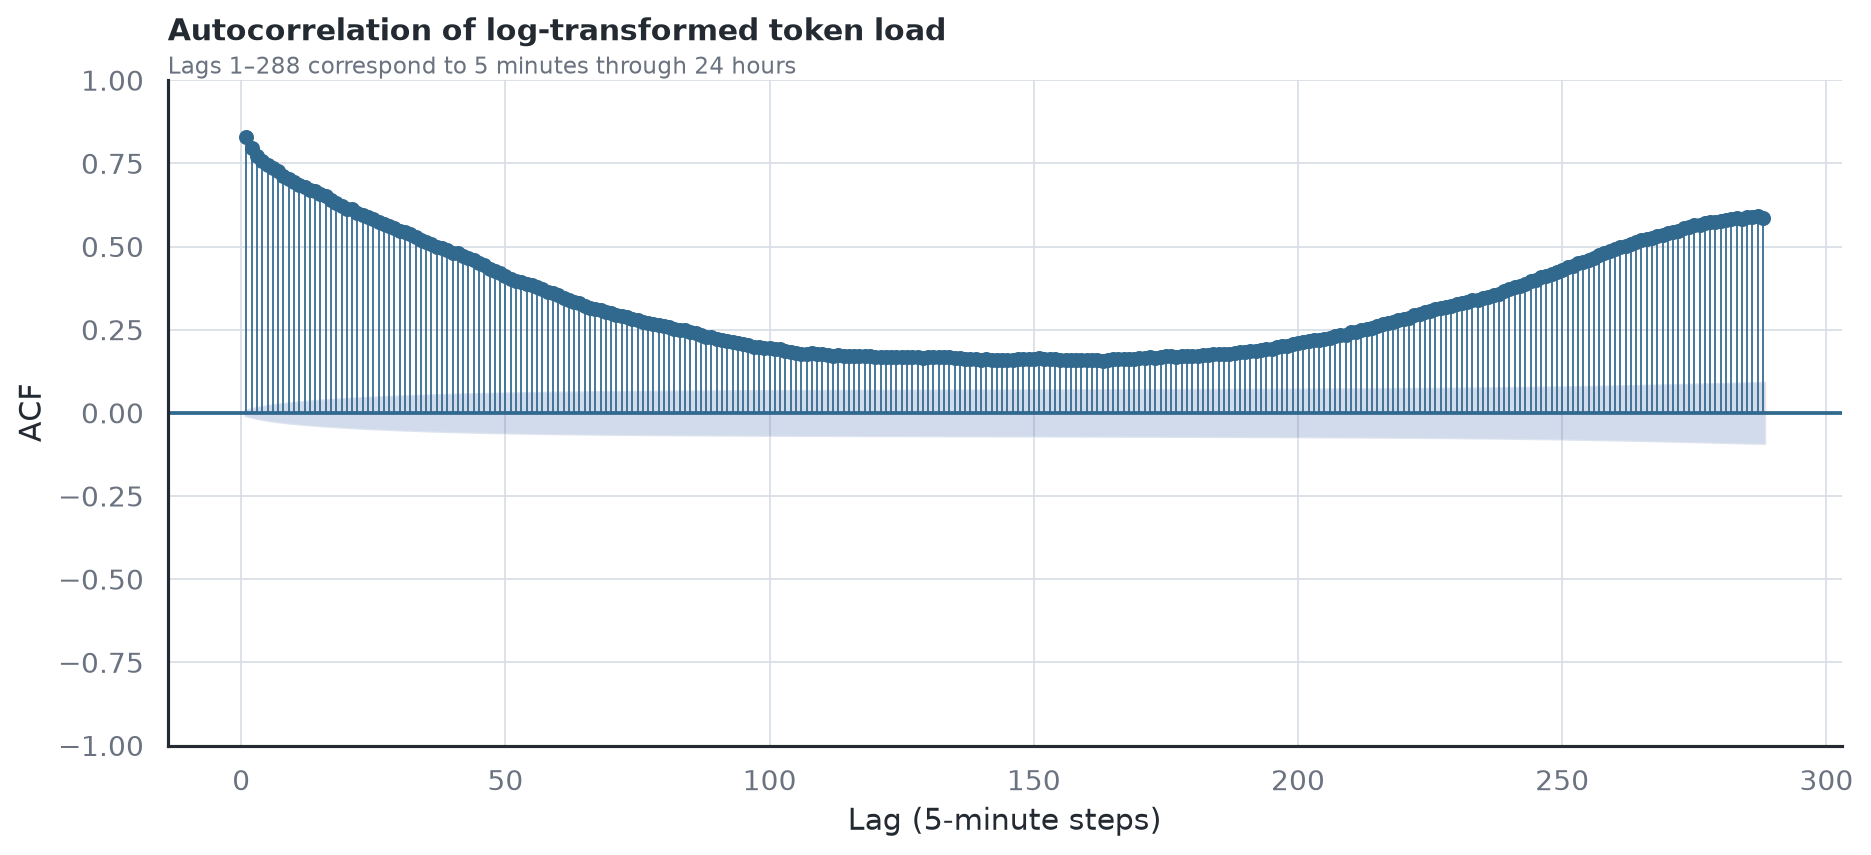

**观察：** log负载在1/3/12/288步的ACF分别为 **0.830/0.772/0.679/0.590**。短期持续性与288步日周期都应进入候选滞后集合，并由验证集比较其增益。

In [10]:
transformed_load = pd.Series(np.log1p(series["token_load"].to_numpy(dtype=float)), index=series.index)
fig, ax = plt.subplots(figsize=(12, 4.8))
plot_acf(transformed_load, lags=288, zero=False, fft=True, ax=ax, title="", color=BLUE, vlines_kwargs={"colors": BLUE, "linewidth": 0.7})
ax.set_title("Autocorrelation of log-transformed token load", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, "Lags 1–288 correspond to 5 minutes through 24 hours", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Lag (5-minute steps)")
ax.set_ylabel("ACF")
ax.spines[["top", "right"]].set_visible(False)
save_and_show(fig, "fig_08_acf_log_load.png")
acf_values = [transformed_load.autocorr(lag=value) for value in (1, 3, 12, 288)]
display(Markdown(
    f"**观察：** log负载在1/3/12/288步的ACF分别为 **{acf_values[0]:.3f}/{acf_values[1]:.3f}/{acf_values[2]:.3f}/{acf_values[3]:.3f}**。"
    "短期持续性与288步日周期都应进入候选滞后集合，并由验证集比较其增益。"
))

### Figure 09 — Partial autocorrelation of log load

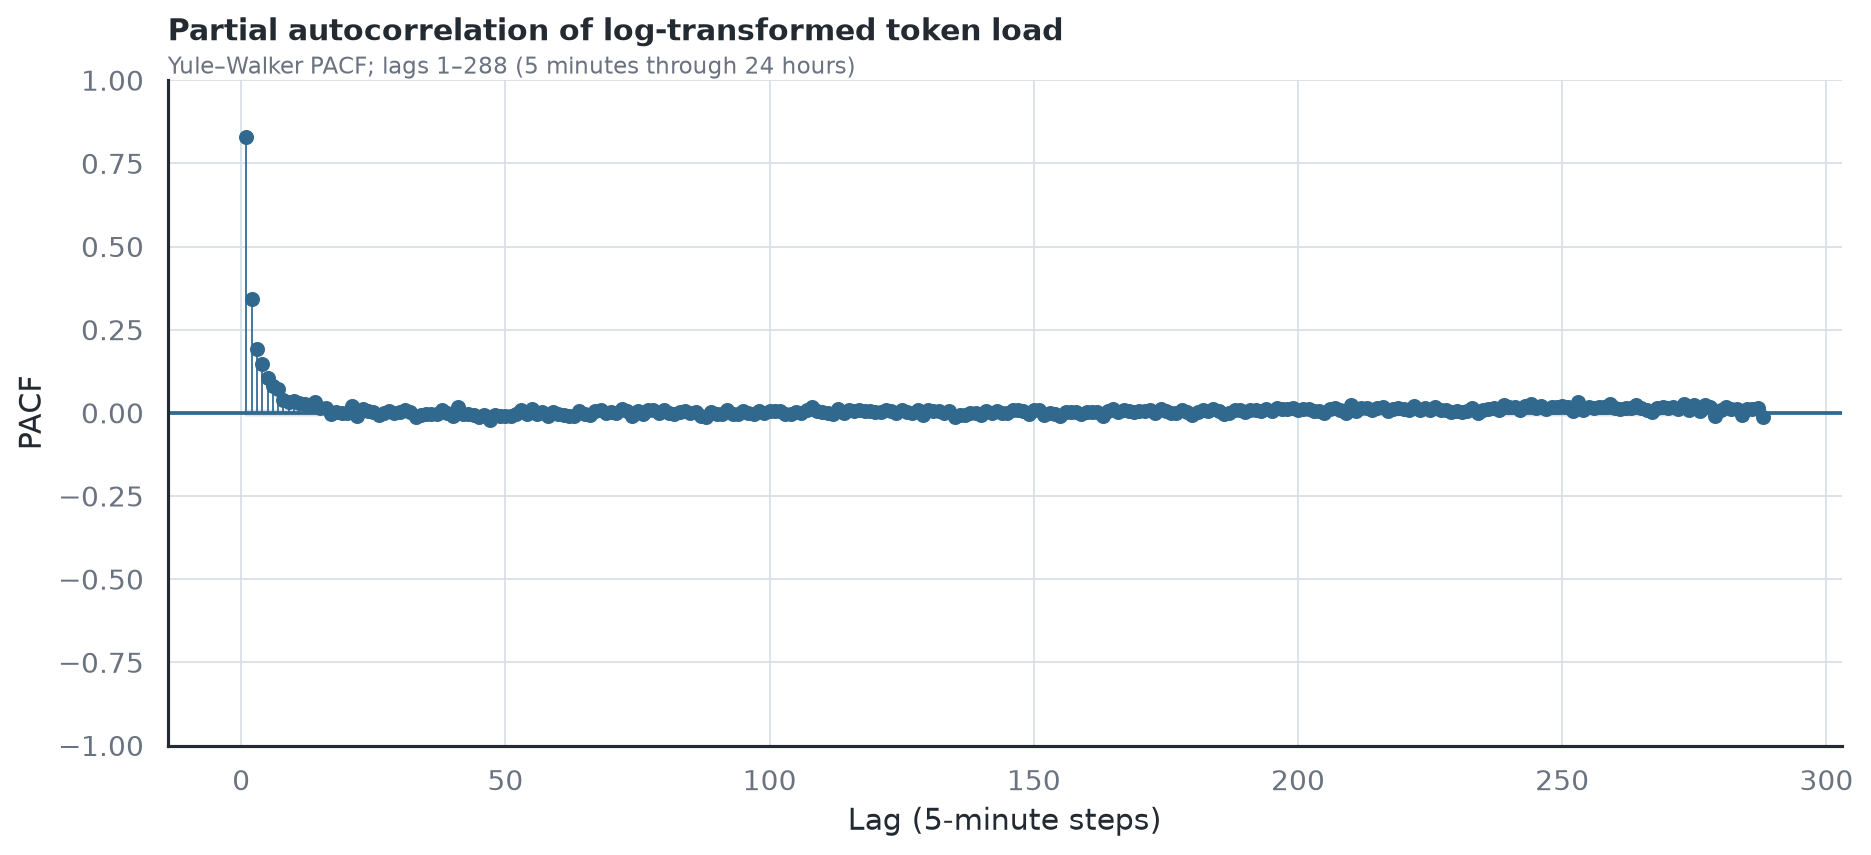

**观察：** 控制中间滞后后，显著性主要集中在靠近原点的短滞后，同时若干更远相位仍保留信号。这支持用稀疏的短滞后、小时级滞后和288步季节滞后，而不是把所有连续滞后都输入模型。

In [11]:
fig, ax = plt.subplots(figsize=(12, 4.8))
plot_pacf(transformed_load, lags=288, zero=False, method="ywm", ax=ax, title="", color=BLUE, vlines_kwargs={"colors": BLUE, "linewidth": 0.7})
ax.set_title("Partial autocorrelation of log-transformed token load", loc="left", fontweight="bold", pad=16)
ax.text(0, 1.01, "Yule–Walker PACF; lags 1–288 (5 minutes through 24 hours)", transform=ax.transAxes, fontsize=9, color=GREY)
ax.set_xlabel("Lag (5-minute steps)")
ax.set_ylabel("PACF")
ax.spines[["top", "right"]].set_visible(False)
save_and_show(fig, "fig_09_pacf_log_load.png")
display(Markdown(
    "**观察：** 控制中间滞后后，显著性主要集中在靠近原点的短滞后，同时若干更远相位仍保留信号。"
    "这支持用稀疏的短滞后、小时级滞后和288步季节滞后，而不是把所有连续滞后都输入模型。"
))

### Figure 10 — Fifteen-minute baselines on a representative test day

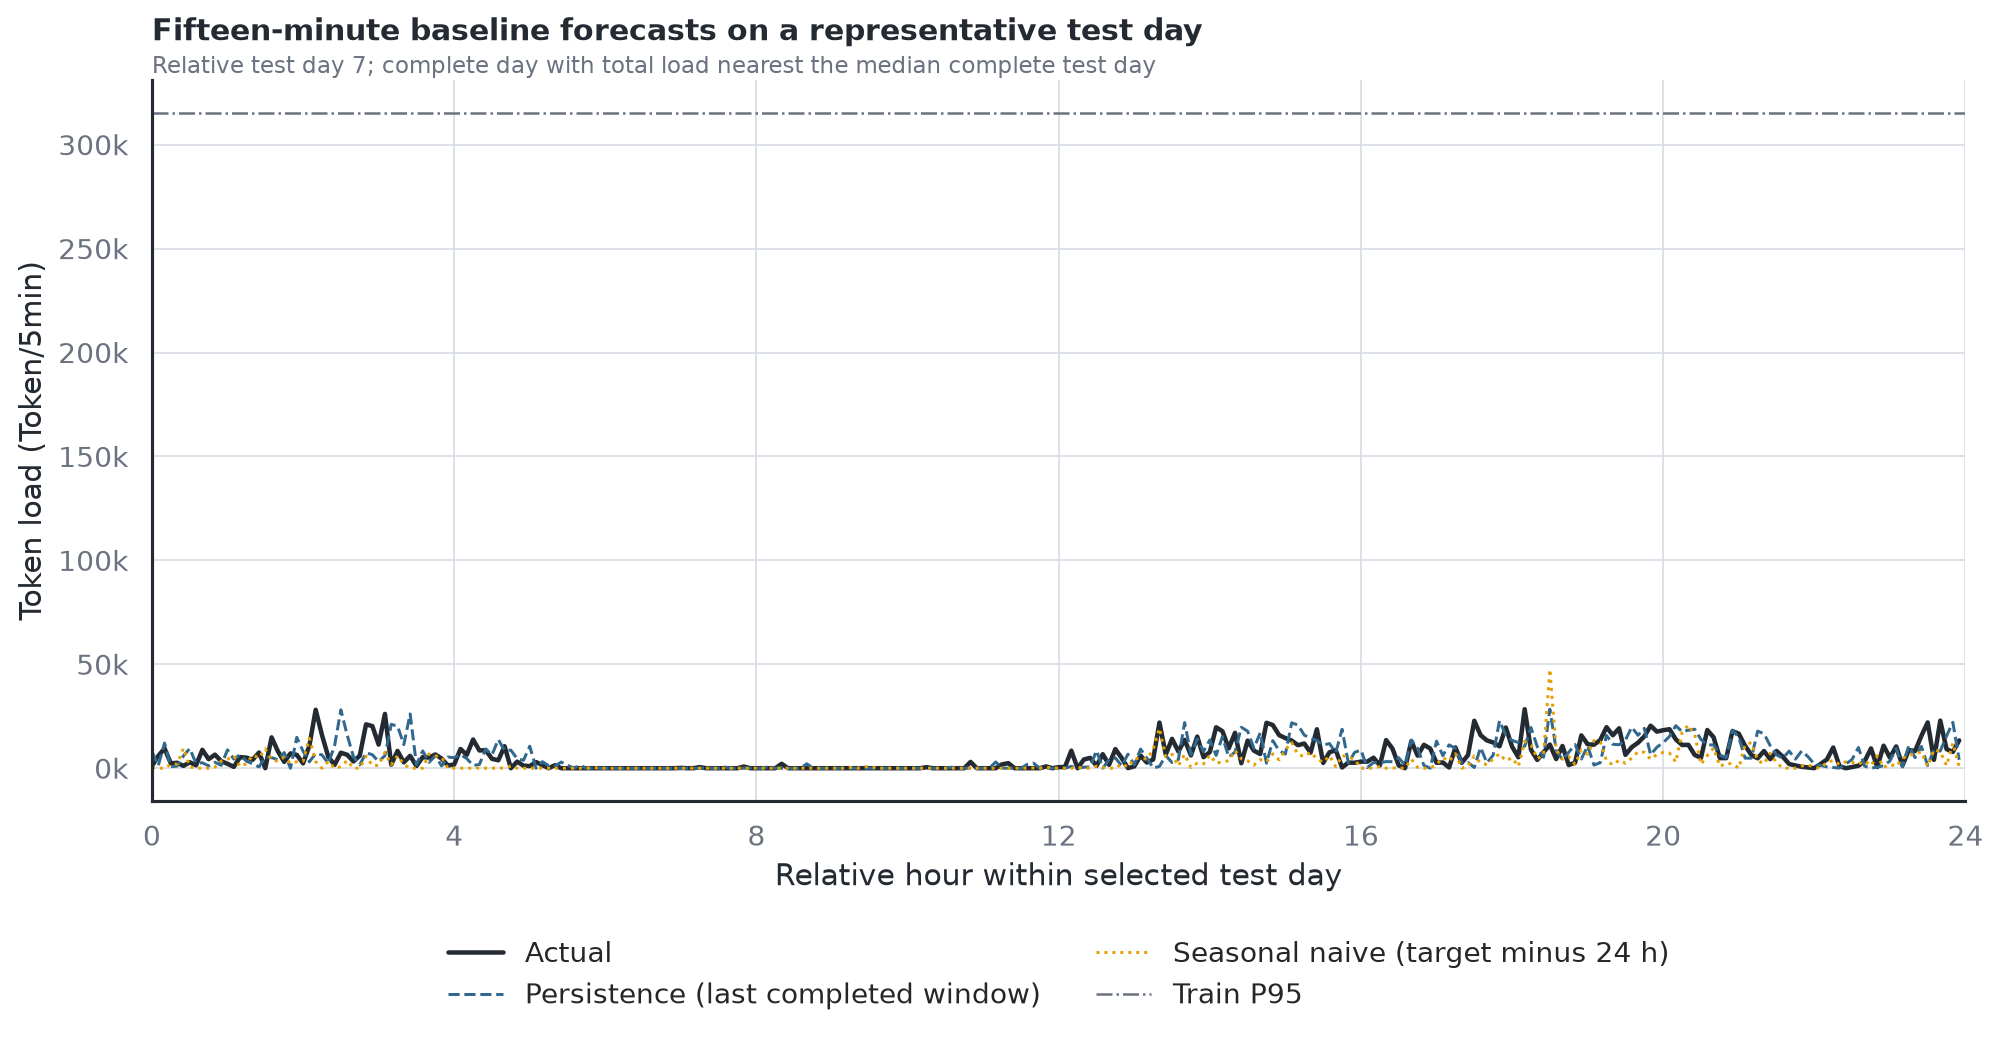

**观察：** 该客观选取的完整测试日中，Persistence/Seasonal Naive 的15分钟 MAE 分别为 **4,563/4,323 Token/5min**。图只说明典型日的逐窗跟随差异，最终模型比较仍以全部5,228个测试目标窗为准。

In [12]:
baseline = pd.read_csv(
    PROJECT_ROOT / "outputs" / "tables" / "pred_baselines_test.csv",
    parse_dates=["timestamp"],
)
baseline["timestamp"] = pd.to_datetime(baseline["timestamp"], utc=True)
baseline["relative_test_day"] = (
    (baseline["timestamp"] - baseline["timestamp"].min())
    // pd.Timedelta(days=1)
).astype(int)
day_stats = baseline.groupby("relative_test_day").agg(
    n_rows=("actual_token_load", "size"),
    total_load=("actual_token_load", "sum"),
)
complete_days = day_stats.loc[day_stats["n_rows"].eq(288)]
representative_day = int(
    (complete_days["total_load"] - complete_days["total_load"].median())
    .abs()
    .idxmin()
)
representative = baseline.loc[
    baseline["relative_test_day"].eq(representative_day)
].copy()
phase_hours = np.arange(len(representative)) * 5 / 60

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.plot(
    phase_hours,
    representative["actual_token_load"],
    color=INK,
    linewidth=1.8,
    label="Actual",
)
ax.plot(
    phase_hours,
    representative["pred_persistence_h15"],
    color=BLUE,
    linewidth=1.2,
    linestyle="--",
    label="Persistence (last completed window)",
)
ax.plot(
    phase_hours,
    representative["pred_seasonal_h15"],
    color=GOLD,
    linewidth=1.2,
    linestyle=":",
    label="Seasonal naive (target minus 24 h)",
)
ax.axhline(TRAIN_P95, color=GREY, linewidth=1.0, linestyle="-.", label="Train P95")
ax.set_title("Fifteen-minute baseline forecasts on a representative test day", loc="left", fontweight="bold", pad=16)
ax.text(
    0,
    1.01,
    f"Relative test day {representative_day}; complete day with total load nearest the median complete test day",
    transform=ax.transAxes,
    fontsize=9,
    color=GREY,
)
ax.set_xlabel("Relative hour within selected test day")
ax.set_ylabel("Token load (Token/5min)")
ax.set_xlim(0, 24)
ax.set_xticks(np.arange(0, 25, 4))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda value, _: f"{value / 1e3:.0f}k"))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.16))
save_and_show(fig, "fig_10_baseline_representative_day.png")
persistence_mae = float(
    np.mean(
        np.abs(
            representative["pred_persistence_h15"]
            - representative["actual_token_load"]
        )
    )
)
seasonal_mae = float(
    np.mean(
        np.abs(
            representative["pred_seasonal_h15"]
            - representative["actual_token_load"]
        )
    )
)
display(Markdown(
    f"**观察：** 该客观选取的完整测试日中，Persistence/Seasonal Naive 的15分钟 MAE 分别为 "
    f"**{persistence_mae:,.0f}/{seasonal_mae:,.0f} Token/5min**。"
    "图只说明典型日的逐窗跟随差异，最终模型比较仍以全部5,228个测试目标窗为准。"
))

## Takeaways

In [13]:
display(Markdown(
    f'''
    1. 完整网格和零窗必须保留：本序列有 **{len(series):,}** 个5分钟窗口，其中 **{int(series['is_zero_window'].sum()):,}** 个为零负载；均值特征在这些窗口保持NaN，后续只能历史填充。
    2. 短期持续性、小时级结构和288步相对日周期均有统计依据，因此 Persistence 与 Seasonal Naive 是必须击败的基线。
    3. 请求数与负载高度相关但不能完全解释Token大小；历史均值、模型构成和Log Type构成是合理候选特征，但必须滞后以避免未来信息泄漏。
    4. 训练期固定P95为 **{TRAIN_P95:,.2f} Token/5min**。由于后续负载与构成存在漂移，突发检测结果必须同时报告固定阈值的跨期适用局限。
    '''
))


    1. 完整网格和零窗必须保留：本序列有 **34,848** 个5分钟窗口，其中 **6,771** 个为零负载；均值特征在这些窗口保持NaN，后续只能历史填充。
    2. 短期持续性、小时级结构和288步相对日周期均有统计依据，因此 Persistence 与 Seasonal Naive 是必须击败的基线。
    3. 请求数与负载高度相关但不能完全解释Token大小；历史均值、模型构成和Log Type构成是合理候选特征，但必须滞后以避免未来信息泄漏。
    4. 训练期固定P95为 **315,246.20 Token/5min**。由于后续负载与构成存在漂移，突发检测结果必须同时报告固定阈值的跨期适用局限。
    